# K-Means vs DBSCAN — Customer Segmentation

**Goal:** Compare two clustering algorithms on real customer data and judge them with 4 metrics.

**The 4 metrics we will use:**

| Metric | Needs true labels? | What it tells you | Good value |
|---|---|---|---|
| **ARI** (Adjusted Rand Index) | ✅ Yes | Agreement between predicted clusters and true labels, corrected for chance | closer to **1** = better |
| **Silhouette Score** | ❌ No | How similar a point is to its own cluster vs the nearest other cluster (−1 to 1) | closer to **1** = better |
| **Davies–Bouldin** | ❌ No | Average ratio of within-cluster scatter to between-cluster separation | closer to **0** = better |
| **Calinski–Harabasz** | ❌ No | Ratio of between-cluster to within-cluster dispersion (variance ratio) | **higher** = better |

> **Important:** ARI can only be computed when you have *ground-truth* labels.
> In real segmentation projects you rarely do — so ARI is used in experiments (like ours)
> to check how much two algorithms agree with each other.


K-Means vs DBSCAN — Customer Segmentation
Goal: Compare K-Means (centroid-based) and DBSCAN (density-based) on the same dataset.

The Plan:

Load and clean the data.
Standardize features so distance calculations are fair.
Use PCA to squash the data into 2D (so we can see it perfectly on a graph).
Run K-Means and DBSCAN on that exact 2D data.
Compare results using metrics and visuals.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Plot settings
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
# 1. Load data
df = pd.read_csv("customer_segmentation_data.csv")
data = df.drop(columns=["id"]) # Drop ID, it's not a feature

# 2. Encode text columns (gender, preferred_category) into numbers
data_encoded = pd.get_dummies(data, columns=["gender", "preferred_category"], drop_first=True)

# 3. Standardize the data (mean=0, variance=1) so 'income' doesn't overpower 'age'
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_encoded)

print(f"Original shape: {df.shape}")
print(f"Processed shape: {X_scaled.shape}")

Original shape: (1000, 9)
Processed shape: (1000, 12)


Step 1: Compress to 2D using PCA
We have 12 features right now. We cannot draw a 12-dimensional graph. PCA compresses our 12 features into 2 features (PC1 and PC2) while keeping the overall layout intact.

Crucial: By doing K-Means and DBSCAN on these 2 features, the clusters we see on the graph will be exactly what the math calculates. No hidden dimensions!

In [3]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"2D PCA shape: {X_pca.shape}")

2D PCA shape: (1000, 2)


Step 2: K-Means - Find the best K
K-Means requires you to choose the number of clusters (K) in advance. We test K from 2 to 10 and look at the Elbow and Silhouette score.

Elbow: Where does the line stop bending? (Lower inertia is better)
Silhouette: How well separated are the clusters? (Higher is better, max 1.0)

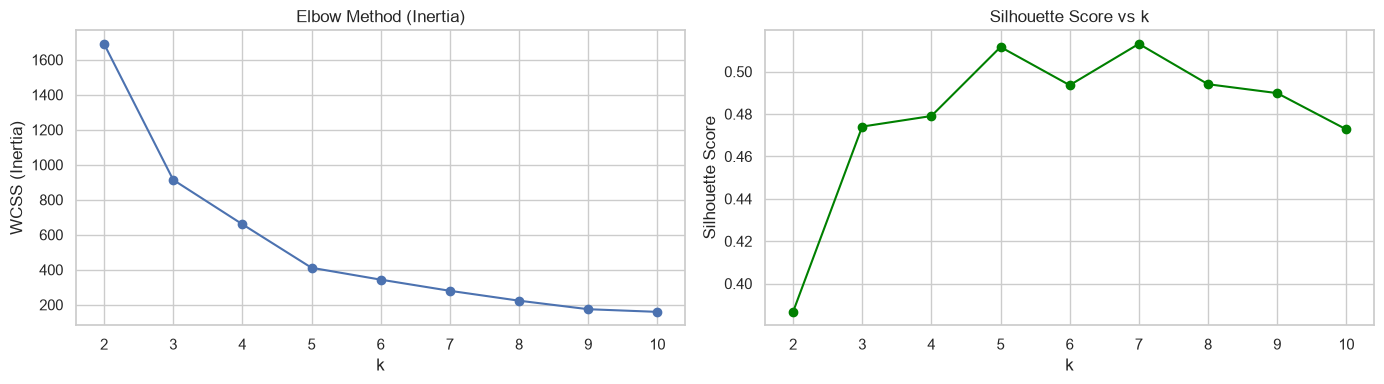

Best k by silhouette: 7


In [4]:
ks = range(2, 11)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(list(ks), inertias, marker="o")
ax[0].set_title("Elbow Method (Inertia)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("WCSS (Inertia)")

ax[1].plot(list(ks), silhouettes, marker="o", color="green")
ax[1].set_title("Silhouette Score vs k")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

best_k = list(ks)[int(np.argmax(silhouettes))]
print(f"Best k by silhouette: {best_k}")

In [5]:
# Train K-Means on the 2D PCA data
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
kmeans_labels = kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

print("K-Means cluster sizes:")
print(pd.Series(kmeans_labels).value_counts().sort_index())

K-Means cluster sizes:
0    106
1    250
2     75
3    252
4     74
5    177
6     66
Name: count, dtype: int64


Step 3: DBSCAN - Find the best Epsilon
DBSCAN doesn't need K. It groups points that are packed closely together within a distance (eps). We use a k-distance plot to find the "knee" (the bend) to pick our eps.

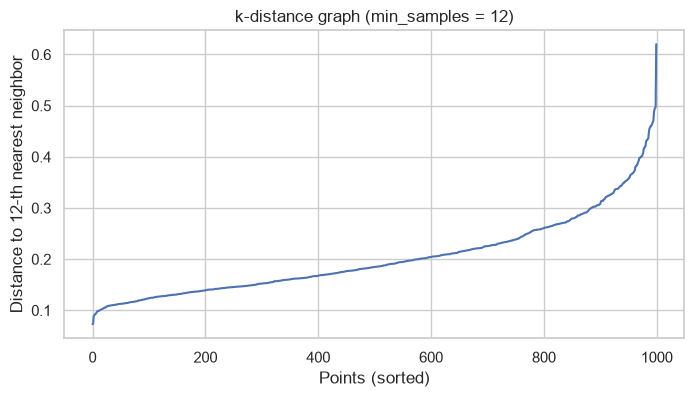

In [6]:
min_samples = 12 # A good rule of thumb for 2D data

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_pca)
distances, _ = neighbors.kneighbors(X_pca)

# Sort distances to the min_samples-th neighbor
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.title(f"k-distance graph (min_samples = {min_samples})")
plt.xlabel("Points (sorted)")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.grid(True)
plt.show()

In [7]:
# Look at the k-distance plot and pick the 'knee' value. 
# 0.5 is usually a great starting point for standardized 2D data.
EPS = 0.25

dbscan = DBSCAN(eps=EPS, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(X_pca)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"DBSCAN found {n_clusters_dbscan} cluster(s) + noise.")
print("\nCluster sizes (label -1 means NOISE/outliers):")
print(pd.Series(dbscan_labels).value_counts().sort_index())

DBSCAN found 6 cluster(s) + noise.

Cluster sizes (label -1 means NOISE/outliers):
-1     56
 0    245
 1    240
 2     53
 3    273
 4     73
 5     60
Name: count, dtype: int64


Step 4: Visual Comparison
Now we plot both algorithms on the exact same 2D PCA data.

K-Means (Left): Plots black "X" centroids. It draws invisible straight lines halfway between these X's to split the data.
DBSCAN (Right): Doesn't use centroids. It connects dots like a spiderweb if they are close enough. Gray dots are "Noise" (outliers) that DBSCAN decided didn't belong to any group.
Note: We use alpha=0.6 (transparency) and smaller dots so overlapping points don't trick your eyes!

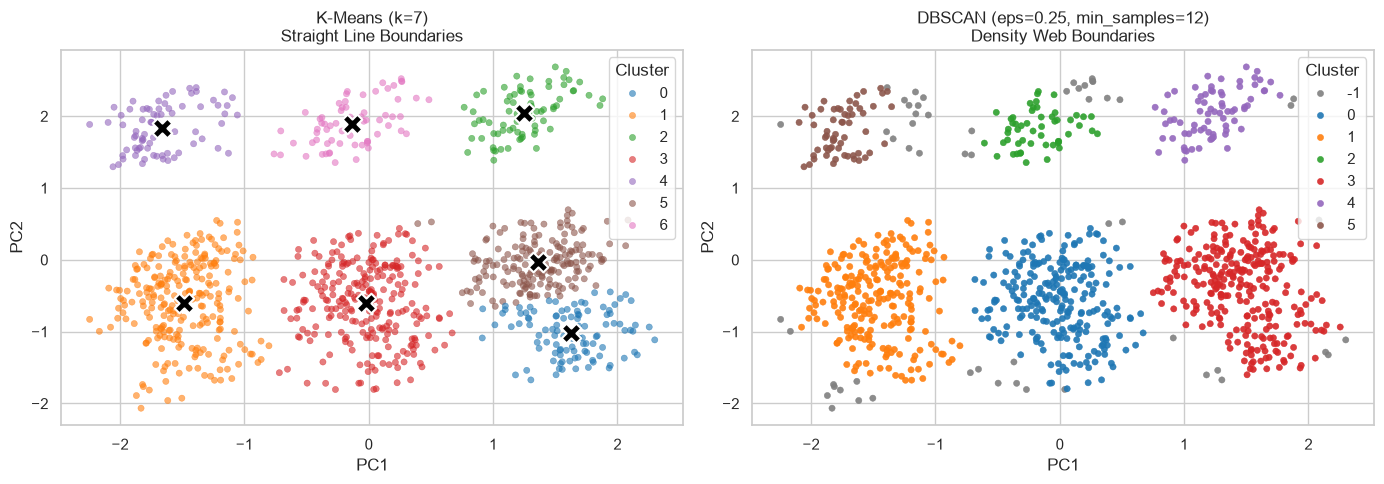

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --- K-Means Plot ---
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=kmeans_labels, palette="tab10", ax=ax[0], s=20, alpha=0.6, edgecolor=None
)
# Add Centroids as large black X's
ax[0].scatter(
    centroids[:, 0], centroids[:, 1], 
    marker='X', s=200, c='black', edgecolors='white', linewidth=1.5, zorder=5
)
ax[0].set_title(f"K-Means (k={best_k})\nStraight Line Boundaries")
ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2")
ax[0].legend(title="Cluster")

# --- DBSCAN Plot ---
# Create a custom palette so noise (-1) shows up as gray
unique_labels = sorted(set(dbscan_labels))
colors = ['gray' if x == -1 else sns.color_palette("tab10")[x] for x in unique_labels]
dbs_palette = dict(zip(unique_labels, colors))

sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=dbscan_labels, palette=dbs_palette, ax=ax[1], s=20, alpha=0.9, edgecolor=None
)
ax[1].set_title(f"DBSCAN (eps={EPS}, min_samples={min_samples})\nDensity Web Boundaries")
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
ax[1].legend(title="Cluster")

plt.tight_layout()
plt.show()

Step 5: Metrics Comparison
We use 3 metrics to judge the algorithms:

Silhouette (higher = better): How similar is a point to its own cluster vs other clusters?
Davies-Bouldin (lower = better): How much do clusters overlap?
Calinski-Harabasz (higher = better): How dense and separated are the clusters?
Note: For DBSCAN, we ignore noise points (-1) when calculating metrics so it isn't unfairly punished for finding outliers.

In [9]:
def evaluate(labels, name):
    # Ignore noise points (-1) for DBSCAN
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        print(f"{name}: Not enough clusters to score.")
        return None
    
    # Evaluate ONLY non-noise points
    X_eval = X_pca[mask]
    labels_eval = labels[mask]
    
    return {
        "Algorithm": name,
        "Silhouette (higher=better)": silhouette_score(X_eval, labels_eval),
        "Davies-Bouldin (lower=better)": davies_bouldin_score(X_eval, labels_eval),
        "Calinski-Harabasz (higher=better)": calinski_harabasz_score(X_eval, labels_eval),
    }

# Evaluate both
results = []
results.append(evaluate(kmeans_labels, "K-Means"))
results.append(evaluate(dbscan_labels, "DBSCAN"))

# Show table
results_df = pd.DataFrame(results).set_index("Algorithm")
results_df

,Silhouette (higher=better),Davies-Bouldin (lower=better),Calinski-Harabasz (higher=better)
Algorithm,,,
K-Means,0.513113,0.652857,1524.533799
DBSCAN,0.546580,0.582497,1430.232714


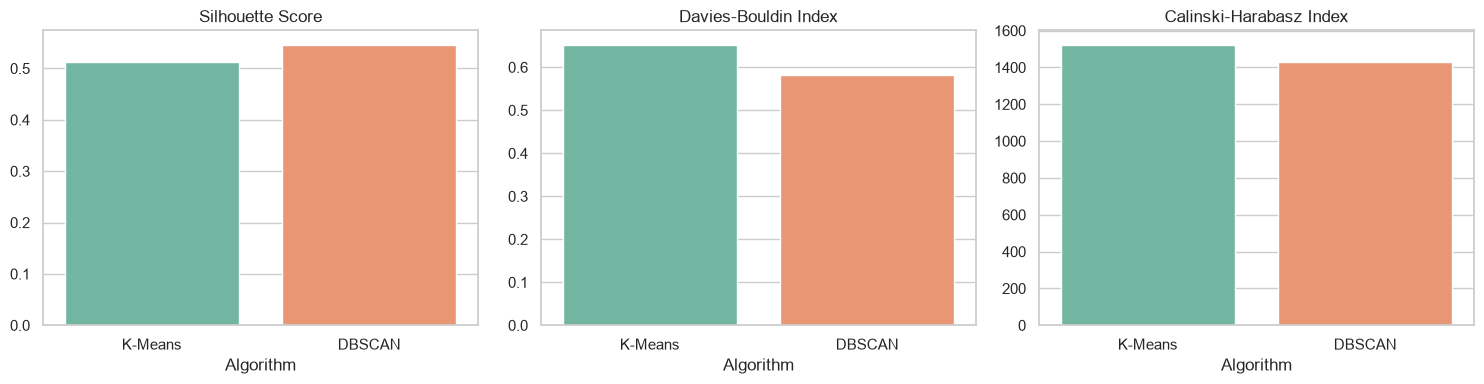

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

metrics_to_plot = ["Silhouette (higher=better)", "Davies-Bouldin (lower=better)", "Calinski-Harabasz (higher=better)"]
titles = ["Silhouette Score", "Davies-Bouldin Index", "Calinski-Harabasz Index"]

for i, m in enumerate(metrics_to_plot):
    sns.barplot(x=results_df.index, y=results_df[m], ax=ax[i], hue=results_df.index, palette="Set2", legend=False)
    ax[i].set_title(titles[i])
    ax[i].set_ylabel("")

plt.tight_layout()
plt.show()

K-Means forces every single point into a cluster and slices the map with straight lines. It's fast and clean, but bad at finding weirdly shaped blobs or outliers.
DBSCAN connects points organically like a spiderweb. It doesn't care about straight lines, and it proudly flags weird points as "Noise" (gray). However, you have to carefully tune eps or it might group everything together or mark everything as noise.

In [11]:
from sklearn.metrics import adjusted_rand_score

# Calculate ARI between K-Means and DBSCAN labels
ari_score = adjusted_rand_score(kmeans_labels, dbscan_labels)

print(f"Adjusted Rand Index (K-Means vs DBSCAN): {ari_score:.4f}")

if ari_score > 0.5:
    print("Interpretation: High agreement. Both algorithms see similar structures in the data.")
elif ari_score > 0.2:
    print("Interpretation: Moderate agreement. They agree on some broad patterns, but define boundaries differently.")
else:
    print("Interpretation: Low agreement. The algorithms see the data very differently (K-Means forces globular clusters, while DBSCAN follows density webs and flags outliers).")

Adjusted Rand Index (K-Means vs DBSCAN): 0.8373
Interpretation: High agreement. Both algorithms see similar structures in the data.


In [12]:
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Grid of parameters to test
eps_values = [0.3, 0.4, 0.5, 0.6]
min_samples_values = [5, 10, 15, 20]

results = []

for eps in eps_values:
    for min_s in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_pca)
        
        # Count clusters and noise (ignoring noise for metrics)
        mask = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        
        if n_clusters > 1 and mask.sum() > 1:
            X_eval = X_pca[mask]
            labels_eval = labels[mask]
            
            results.append({
                "eps": eps,
                "min_samples": min_s,
                "n_clusters": n_clusters,
                "n_noise": n_noise,
                "Silhouette": round(silhouette_score(X_eval, labels_eval), 4),
                "Davies-Bouldin": round(davies_bouldin_score(X_eval, labels_eval), 4),
                "Calinski-Harabasz": round(calinski_harabasz_score(X_eval, labels_eval), 2)
            })
        else:
            # Not enough clusters to calculate metrics
            results.append({
                "eps": eps,
                "min_samples": min_s,
                "n_clusters": n_clusters,
                "n_noise": n_noise,
                "Silhouette": None,
                "Davies-Bouldin": None,
                "Calinski-Harabasz": None
            })

# Display the table
results_df = pd.DataFrame(results)
results_df

,eps,min_samples,n_clusters,n_noise,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,0.3,5,4,0,0.3656,0.6145,295.94
1,0.3,10,4,7,0.3683,0.6125,295.41
2,0.3,15,6,30,0.5382,0.5965,1452.42
3,0.3,20,6,55,0.5465,0.5775,1434.06
4,0.4,5,2,0,0.4393,0.9708,561.80
5,0.4,10,3,0,0.3863,0.7090,403.59
6,0.4,15,4,1,0.3660,0.6143,296.42
7,0.4,20,4,3,0.3664,0.6144,296.60
8,0.5,5,2,0,0.4393,0.9708,561.80
9,0.5,10,2,0,0.4393,0.9708,561.80
